# Dataset 5: Reddit Mental Health Posts — Data Cleaning & Preprocessing
**Model target:** Model 2 — Mental Health Condition Classifier
**HuggingFace:** `solomonk/reddit_mental_health_posts`
**Link:** https://huggingface.co/datasets/solomonk/reddit_mental_health_posts
**License:** No restrictions — freely accessible, no login
**Size:** 151,000 rows
**Task:** Multi-label MH condition classification: depression, anxiety, stress, burnout, PTSD

---
## 5.1 Dataset Description

151,000 Reddit posts from mental health subreddits with subreddit labels (ADHD, depression, anxiety, etc.). Each post is labelled by which subreddit it came from. We convert these subreddit labels into our 5 target condition labels using keyword detection — capturing comorbidity that subreddit labels alone miss.

## 5.2 Why Multi-Label?
A post from r/depression often mentions anxiety and burnout in the same text. Using only the subreddit label loses this information. We scan every post for all 5 condition vocabularies simultaneously and assign all matching labels — this reflects real-world comorbidity.

In [1]:
import re, json, hashlib, unicodedata
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from itertools import combinations
from collections import Counter
from datasets import load_dataset, Dataset, DatasetDict
from sklearn.model_selection import train_test_split

sns.set_theme(style='whitegrid')
plt.rcParams['figure.dpi'] = 110
import os; os.makedirs('figures', exist_ok=True)
os.makedirs('data/cleaned', exist_ok=True)

CONDITIONS = ['depression', 'anxiety', 'stress', 'burnout', 'ptsd']

# Condition keyword vocabulary
# Each keyword is a case-insensitive substring match
CONDITION_KEYWORDS = {
    'depression': ['depress','hopeless','worthless','empty inside',
                   'no reason to live','can\'t get out of bed','crying myself',
                   'anhedonia','feel nothing','numb','despair','miserable',
                   'no future','suicid','wish i was dead'],
    'anxiety':    ['anxi','panic attack','worry','nervous','scared',
                   'phobia','ocd','obsess','compuls','racing heart',
                   'can\'t stop thinking','overthink','dread','tense',
                   'on edge','social anxi'],
    'stress':     ['stress','overwhelm','pressure','too much','can\'t cope',
                   'breaking point','burned out','deadlines','exhausted from',
                   'no energy','stretched thin','drowning in'],
    'burnout':    ['burnout','burnt out','burned out','emotionally drained',
                   'drained','no motivation','can\'t work','work is killing',
                   'hate my job','can\'t function','completely exhausted',
                   'nothing left'],
    'ptsd':       ['ptsd','trauma','abuse','flashback','nightmare',
                   'trigger','survivor','assault','hypervigilant',
                   'intrusive thought','can\'t forget','haunted by'],
}

print('Libraries and condition keywords loaded.')

Libraries and condition keywords loaded.


In [2]:
# Load dataset
print("Loading solomonk/reddit_mental_health_posts...")
raw = load_dataset("solomonk/reddit_mental_health_posts")
print(raw)
df = raw['train'].to_pandas()
print(f"\nShape: {df.shape}")
print(f"Columns: {df.columns.tolist()}")
print(f"\nSubreddit distribution:")
print(df['subreddit'].value_counts())
print(f"\nNull values:")
print(df.isnull().sum())
print(f"\nSample row:")
print(df.iloc[0][['subreddit','title','body']].to_dict())

Loading solomonk/reddit_mental_health_posts...


Repo card metadata block was not found. Setting CardData to empty.


DatasetDict({
    train: Dataset({
        features: ['author', 'body', 'created_utc', 'id', 'num_comments', 'score', 'subreddit', 'title', 'upvote_ratio', 'url'],
        num_rows: 151288
    })
})

Shape: (151288, 10)
Columns: ['author', 'body', 'created_utc', 'id', 'num_comments', 'score', 'subreddit', 'title', 'upvote_ratio', 'url']

Subreddit distribution:
subreddit
OCD           42826
ADHD          37109
depression    24031
ptsd          24028
aspergers     23294
Name: count, dtype: int64

Null values:
author             0
body            1609
created_utc        0
id                 0
num_comments       0
score              0
subreddit          0
title              0
upvote_ratio       0
url                0
dtype: int64

Sample row:
{'subreddit': 'ADHD', 'title': 'I get extremely anxious if I’m not working 24/7', 'body': 'A few months ago I was accepted into this full time software engineering fellowship and it’s made me realize that I CANNOT work sustainably to save my life. It

In [3]:
# PROBLEM 1: Single subreddit label misses comorbidity
print("PROBLEM 1: Subreddit label = single weak proxy")
print("=" * 50)

# Combine title + body for richer text
df['text'] = (df['title'].fillna('') + ' ' + df['body'].fillna('')).str.strip()
df['word_count'] = df['text'].apply(lambda x: len(str(x).split()))

# Demonstrate the comorbidity problem
print("\nExample: post from r/depression that also mentions anxiety:")
depression_posts = df[df['subreddit'] == 'depression']['text']
multi_condition = []
for text in depression_posts.head(200):
    found = []
    t = str(text).lower()
    for cond, kws in CONDITION_KEYWORDS.items():
        if any(kw in t for kw in kws):
            found.append(cond)
    if len(found) > 1:
        multi_condition.append((found, text[:100]))
        if len(multi_condition) == 3:
            break

for conds, text in multi_condition:
    print(f"  Conditions found: {conds}")
    print(f"  Text: {text}...")
    print()

print(f"FIX: Use keyword detection across ALL 5 conditions")
print(f"     to capture co-occurring conditions in every post")

PROBLEM 1: Subreddit label = single weak proxy

Example: post from r/depression that also mentions anxiety:
  Conditions found: ['depression', 'ptsd']
  Text: Why am I? Hello, I have been asking this question for a long time and I really have no idea what the...

  Conditions found: ['depression', 'anxiety', 'ptsd']
  Text: what’s therapy like? (not rily sure when to use trigger warnings, but i'll put them here just in cas...

  Conditions found: ['depression', 'anxiety', 'stress']
  Text: Where can I get help? Idk if this is the place for this, but I need help. I'm broke, no car, no job,...

FIX: Use keyword detection across ALL 5 conditions
     to capture co-occurring conditions in every post


In [4]:
# PROBLEM 2: Text quality issues
print("PROBLEM 2: Text quality issues")
print("=" * 50)

empty         = (df['text'].str.strip() == '').sum()
very_short    = (df['word_count'] < 8).sum()
very_long     = (df['word_count'] > 300).sum()
exact_dupes   = df['text'].duplicated().sum()
deleted_posts = df['text'].str.contains(r'\[deleted\]|\[removed\]',
                                         regex=True, na=False).sum()

print(f"Empty posts           : {empty}")
print(f"Under 8 words         : {very_short}")
print(f"Over 300 words        : {very_long}")
print(f"Exact duplicates      : {exact_dupes}")
print(f"[deleted]/[removed]   : {deleted_posts}")
print()
print("FIX:")
print("  - Remove empty / [deleted] / [removed]")
print("  - Filter < 8 words (need context for condition detection)")
print("  - Truncate > 300 words")
print("  - Deduplicate by MD5 hash")

PROBLEM 2: Text quality issues
Empty posts           : 0
Under 8 words         : 28031
Over 300 words        : 13786
Exact duplicates      : 3016
[deleted]/[removed]   : 62669

FIX:
  - Remove empty / [deleted] / [removed]
  - Filter < 8 words (need context for condition detection)
  - Truncate > 300 words
  - Deduplicate by MD5 hash


In [5]:
# CLEANING FUNCTION
RE_URL    = re.compile(r'https?://\S+|www\.\S+')
RE_HTML   = re.compile(r'&amp;|&lt;|&gt;|&quot;')
RE_DEL    = re.compile(r'\[deleted\]|\[removed\]', re.IGNORECASE)
RE_SPACE  = re.compile(r'[ \t]+')

def clean_mh_text(text, min_words=8, max_words=300):
    """
    Clean Reddit mental health post for condition classification.

    min_words=8 (higher than emotion cleaning):
      Reason: We need enough text context for keyword-based
      condition detection. A 5-word post rarely contains
      enough clinical language to reliably detect conditions.
      'I feel depressed' is 4 words but 'I have been feeling
      deeply depressed and anxious every morning' at 12 words
      contains much more classifiable signal.

    Combined title + body:
      Reason: Reddit titles are often a summary of the condition
      ('I think I have burnout') while the body elaborates.
      Both together give the richest text for condition detection.
    """
    if not isinstance(text, str) or not text.strip():
        return None
    text = unicodedata.normalize('NFKC', text)
    text = RE_URL.sub(' ', text)
    text = RE_HTML.sub(' ', text)
    text = RE_DEL.sub(' ', text)
    text = RE_SPACE.sub(' ', text).strip()
    words = text.split()
    if len(words) < min_words:
        return None
    return ' '.join(words[:max_words])

def assign_conditions(text):
    """
    Assign multi-label conditions via keyword matching.

    Returns:
      conditions: list of matched condition names
      vector:     [1,0,1,0,0] binary array (length 5)
    """
    t = str(text).lower()
    conditions = [cond for cond, kws in CONDITION_KEYWORDS.items()
                  if any(kw in t for kw in kws)]
    vector = [1 if c in conditions else 0 for c in CONDITIONS]
    return conditions, vector

# Test
tests = [
    "I have been feeling deeply depressed for weeks, can't stop crying",
    "panic attacks every morning, so anxious I can't leave the house",
    "completely burned out from work, no energy left, emotionally drained",
    "having ptsd flashbacks and feel anxious all the time since the trauma",
    "hello reddit",  # no condition
]
print("Condition assignment tests:")
for t in tests:
    conds, vec = assign_conditions(t)
    print(f"  Text : {t[:60]}")
    print(f"  Found: {conds} | Vector: {vec}")
    print()

Condition assignment tests:
  Text : I have been feeling deeply depressed for weeks, can't stop c
  Found: ['depression'] | Vector: [1, 0, 0, 0, 0]

  Text : panic attacks every morning, so anxious I can't leave the ho
  Found: ['anxiety'] | Vector: [0, 1, 0, 0, 0]

  Text : completely burned out from work, no energy left, emotionally
  Found: ['stress', 'burnout'] | Vector: [0, 0, 1, 1, 0]

  Text : having ptsd flashbacks and feel anxious all the time since t
  Found: ['anxiety', 'ptsd'] | Vector: [0, 1, 0, 0, 1]

  Text : hello reddit
  Found: [] | Vector: [0, 0, 0, 0, 0]



In [6]:
# APPLY CLEANING
rows = []
stats = {'kept':0,'too_short':0,'no_condition':0,'null':0}
seen_hashes = set()
dupes = 0

for _, row in df.iterrows():
    text = str(row.get('title','')) + ' ' + str(row.get('body',''))
    cleaned = clean_mh_text(text)

    if cleaned is None:
        stats['null' if not text.strip() else 'too_short'] += 1
        continue

    conditions, vector = assign_conditions(cleaned)
    if not conditions:
        stats['no_condition'] += 1
        continue

    h = hashlib.md5(re.sub(r'\s+','',cleaned.lower()).encode()).hexdigest()
    if h in seen_hashes:
        dupes += 1
        continue
    seen_hashes.add(h)

    rows.append({'text': cleaned, 'conditions': conditions,
                 'condition_vector': vector,
                 'source': 'reddit_mh_posts'})
    stats['kept'] += 1

print(f"Original : {len(df):,}")
print(f"Kept     : {stats['kept']:,} ({stats['kept']/len(df)*100:.1f}%)")
print(f"Too short: {stats['too_short']:,}")
print(f"No cond  : {stats['no_condition']:,}")
print(f"Dupes    : {dupes:,}")

Original : 151,288
Kept     : 68,792 (45.5%)
Too short: 33,081
No cond  : 49,162
Dupes    : 253


Condition frequency:
  anxiety     : 42,948 (62.4%) ███████████████████████████████
  ptsd        : 24,228 (35.2%) █████████████████
  depression  : 19,617 (28.5%) ██████████████
  stress      : 12,081 (17.6%) ████████
  burnout     : 1,760 (2.6%) █

Top co-occurrences:
  anxiety      + ptsd        : 11,772
  anxiety      + depression  : 8,860
  anxiety      + stress      : 5,935
  depression   + ptsd        : 4,691
  ptsd         + stress      : 3,146
  depression   + stress      : 3,047


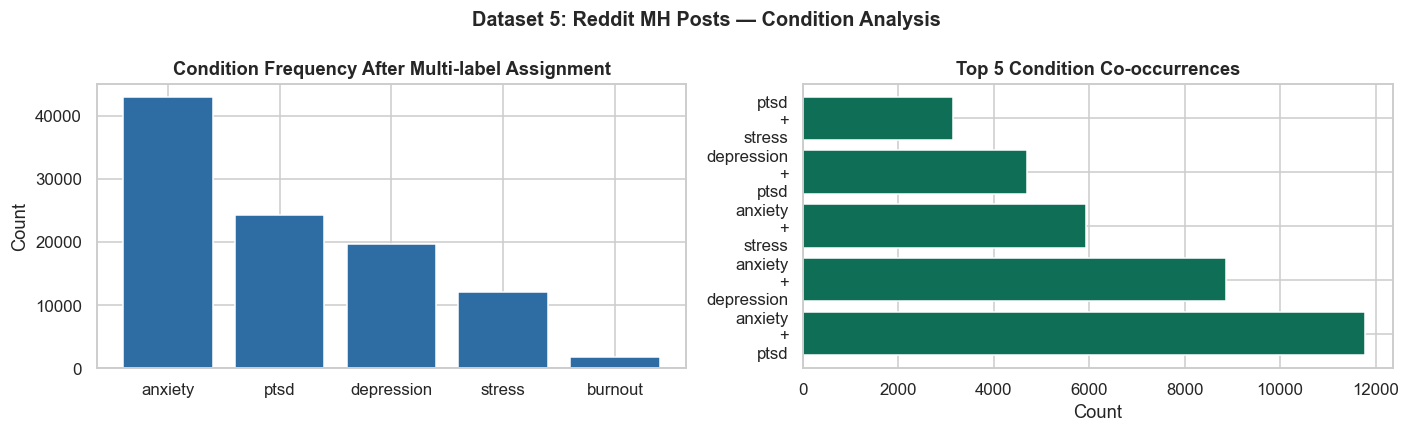

In [7]:
# CO-OCCURRENCE ANALYSIS — dissertation figure
clean_df = pd.DataFrame(rows)

# Condition frequency
freq = {c: sum(1 for r in rows if c in r['conditions']) for c in CONDITIONS}
print("Condition frequency:")
for cond, cnt in sorted(freq.items(), key=lambda x: x[1], reverse=True):
    pct = cnt/len(rows)*100
    bar = '█' * int(pct/2)
    print(f"  {cond:12s}: {cnt:,} ({pct:.1f}%) {bar}")

# Co-occurrence pairs
co_occur = Counter()
for r in rows:
    for pair in combinations(sorted(r['conditions']), 2):
        co_occur[pair] += 1

print("\nTop co-occurrences:")
for pair, count in co_occur.most_common(6):
    print(f"  {pair[0]:12s} + {pair[1]:12s}: {count:,}")

# Plot
fig, axes = plt.subplots(1, 2, figsize=(13, 4))

conditions_sorted = sorted(freq.items(), key=lambda x: x[1], reverse=True)
axes[0].bar([x[0] for x in conditions_sorted],
            [x[1] for x in conditions_sorted],
            color='#2E6DA4', edgecolor='white')
axes[0].set_title('Condition Frequency After Multi-label Assignment',
                   fontweight='bold')
axes[0].set_ylabel('Count')

labels_clean = [f"{p[0]}\n+\n{p[1]}" for p,_ in co_occur.most_common(5)]
counts_clean = [c for _,c in co_occur.most_common(5)]
axes[1].barh(labels_clean, counts_clean, color='#0F6E56', edgecolor='white')
axes[1].set_title('Top 5 Condition Co-occurrences', fontweight='bold')
axes[1].set_xlabel('Count')

plt.suptitle('Dataset 5: Reddit MH Posts — Condition Analysis', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('figures/05a_reddit_mh_conditions.png', dpi=150, bbox_inches='tight')
plt.show()

In [8]:
# SPLIT AND SAVE
from datasets import Dataset, DatasetDict
from sklearn.model_selection import train_test_split as sk_split

clean_df = clean_df.sample(frac=1, random_state=42).reset_index(drop=True)
n = len(clean_df)
train_df = clean_df.iloc[:int(n*0.8)]
val_df   = clean_df.iloc[int(n*0.8):int(n*0.9)]
test_df  = clean_df.iloc[int(n*0.9):]

ds = DatasetDict({
    'train':      Dataset.from_pandas(train_df, preserve_index=False),
    'validation': Dataset.from_pandas(val_df,   preserve_index=False),
    'test':       Dataset.from_pandas(test_df,  preserve_index=False),
})
ds.save_to_disk('data/cleaned/reddit_mh_posts')

print(f"Saved. train={len(train_df):,}, val={len(val_df):,}, test={len(test_df):,}")

# Push to HuggingFace Hub
print('\nPushing to HuggingFace Hub...')
try:
    repo_id = 'AmiruMallawarachchi/mindlens-reddit-mh-cleaned'
    ds.push_to_hub(repo_id, private=True)
    print(f'✓ Successfully pushed to HuggingFace: {repo_id}')
except Exception as e:
    print(f'⚠ Could not push to HuggingFace: {type(e).__name__}: {e}')
    print('  Make sure you are logged in with huggingface-cli login and have permission to access the repo.')

print("\n✓ Notebook 5 complete.")

Saving the dataset (0/1 shards):   0%|          | 0/55033 [00:00<?, ? examples/s]

Saving the dataset (0/1 shards):   0%|          | 0/6879 [00:00<?, ? examples/s]

Saving the dataset (0/1 shards):   0%|          | 0/6880 [00:00<?, ? examples/s]

Saved. train=55,033, val=6,879, test=6,880

Pushing to HuggingFace Hub...


Uploading the dataset shards:   0%|          | 0/1 [00:00<?, ?it/s]

...

Uploading files as bytes or binary IO objects is not supported by Xet Storage. Falling back to HTTP upload.


Uploading the dataset shards:   0%|          | 0/1 [00:00<?, ?it/s]

Creating parquet from Arrow format:   0%|          | 0/7 [00:00<?, ?ba/s]

Uploading files as bytes or binary IO objects is not supported by Xet Storage. Falling back to HTTP upload.


✓ Successfully pushed to HuggingFace: AmiruMallawarachchi/mindlens-reddit-mh-cleaned

✓ Notebook 5 complete.


## 5.8 Preprocessing Summary

| Step | Problem | Fix | Reason |
|------|---------|-----|--------|
| 1 | Single subreddit label | Multi-label keyword detection | Captures real comorbidity |
| 2 | Title + body separate | Combine into one text | Richer context for detection |
| 3 | URLs and HTML | Remove | No condition signal |
| 4 | [deleted]/[removed] | Filter | Empty content |
| 5 | min_words=8 | Higher threshold than emotion | Need context for keyword matching |
| 6 | Duplicates | MD5 dedup | Prevent train/test leakage |
| 7 | No condition match | Filter out | Off-topic posts = noise |
| 8 | condition_vector | 5-dim binary array | BCEWithLogitsLoss format |

**Combined with Dataset 6** (ourafla/Mental-Health_Text-Classification_Dataset) in the Master Summary notebook for the full Model 2 training set.